In [29]:
""" Check the inter-station variability in HBR's precipitation, temperature forcings,
    and streamflow, in the bigger watershed (not limited to Watershed 1) """
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

/tmp/ipykernel_1442765/2348056219.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  streamflow = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'data', 'Hubbard_Brook',


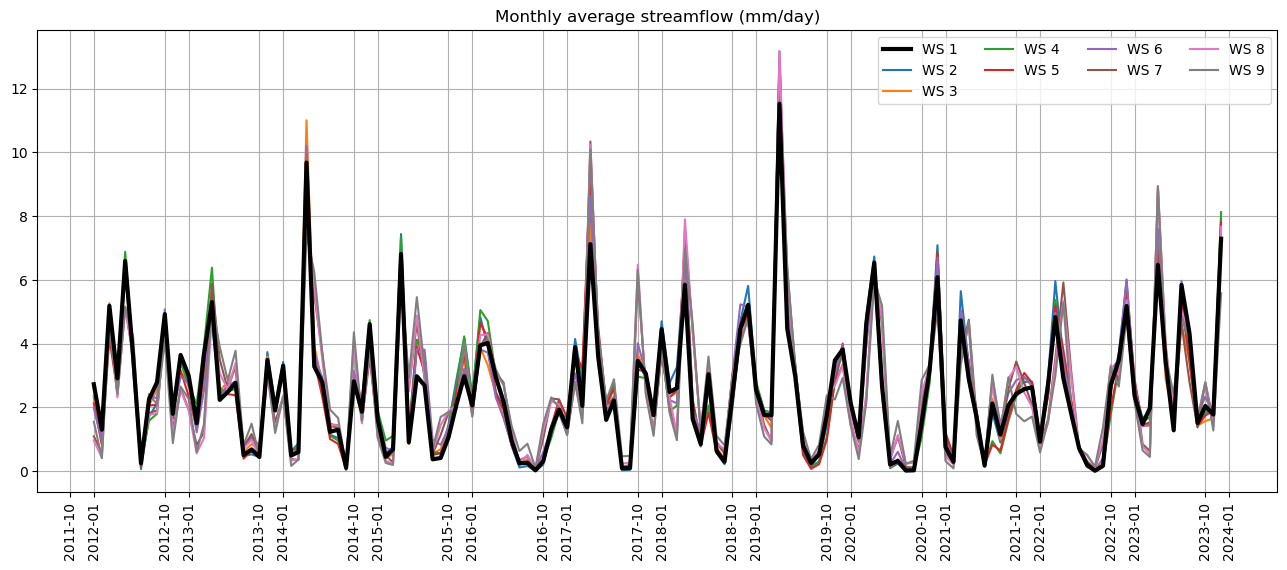

In [15]:
streamflow = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'data', 'Hubbard_Brook',
                                      'knb-lter-hbr.2.14', 'HBEF_DailyStreamflow_1956-2023.csv'),
                         index_col=[0,1], parse_dates=True)['Streamflow'].unstack()
streamflow = streamflow.dropna(axis = 0, how = 'any').resample('1MS').mean()
streamflow = streamflow.loc[streamflow.index.year >= 2012, :]

fig, ax = plt.subplots(figsize = (16, 6))
for ws in streamflow.columns:
    if ws == 1:
        ax.plot(streamflow.index, streamflow[ws], lw = 3, color = 'k', 
                label = f'WS {ws}', zorder = 3)
    else:
        ax.plot(streamflow.index, streamflow[ws], label = f'WS {ws}')
ax.set_title('Monthly average streamflow (mm/day)')
ax.legend(ncol = 4)
plt.setp(ax.get_xticklabels(), rotation = 90)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.grid(True)

/tmp/ipykernel_1442765/540532099.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  precipitation = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'data', 'Hubbard_Brook',


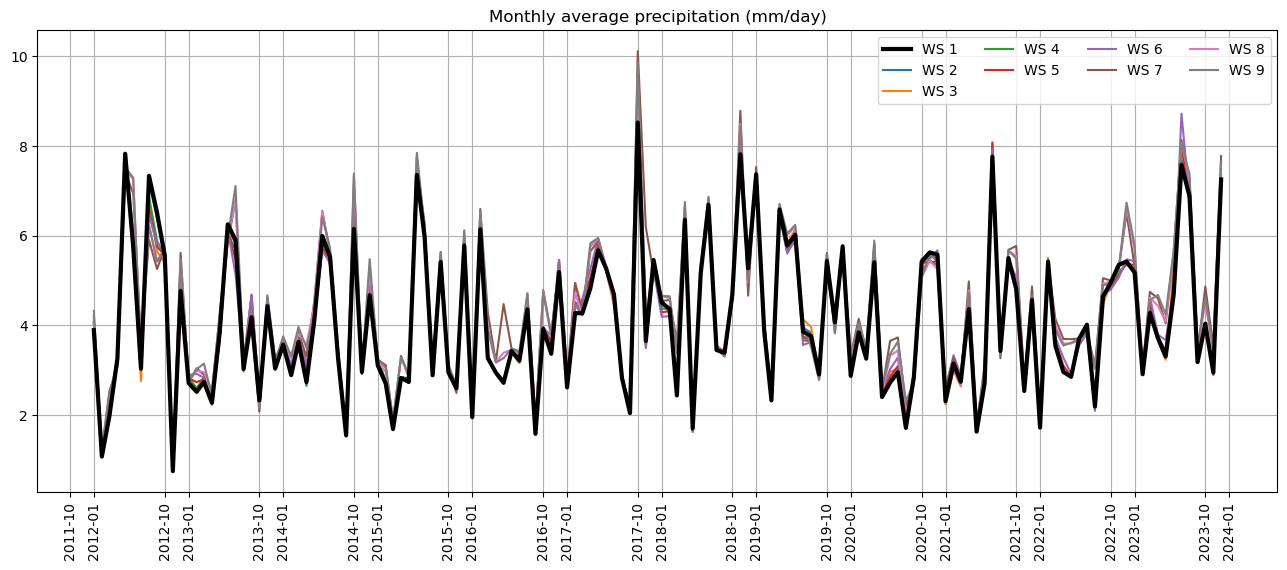

In [16]:
precipitation = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'data', 'Hubbard_Brook',
                            'knb-lter-hbr.14.18', 'dailyWatershedPrecip1956-2023.csv'), 
                            index_col = [0,1], parse_dates = True)['Precip'].unstack()
precipitation = precipitation.dropna(axis = 0, how = 'any')
precipitation = precipitation.loc[precipitation.index.year >= 2012, :]
precipitation = precipitation.resample('1MS').mean()

fig, ax = plt.subplots(figsize = (16, 6))
for ws in precipitation.columns:
    if ws == 'W1':
        ax.plot(precipitation.index, precipitation[ws], lw = 3, color = 'k', 
                label = f'WS {ws[1]}', zorder = 3)
    else:
        ax.plot(precipitation.index, precipitation[ws], label = f'WS {ws[1]}')
ax.set_title('Monthly average precipitation (mm/day)')
ax.legend(ncol = 4)
plt.setp(ax.get_xticklabels(), rotation = 90)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.grid(True)

/tmp/ipykernel_1442765/340984843.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tair = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'data', 'Hubbard_Brook',


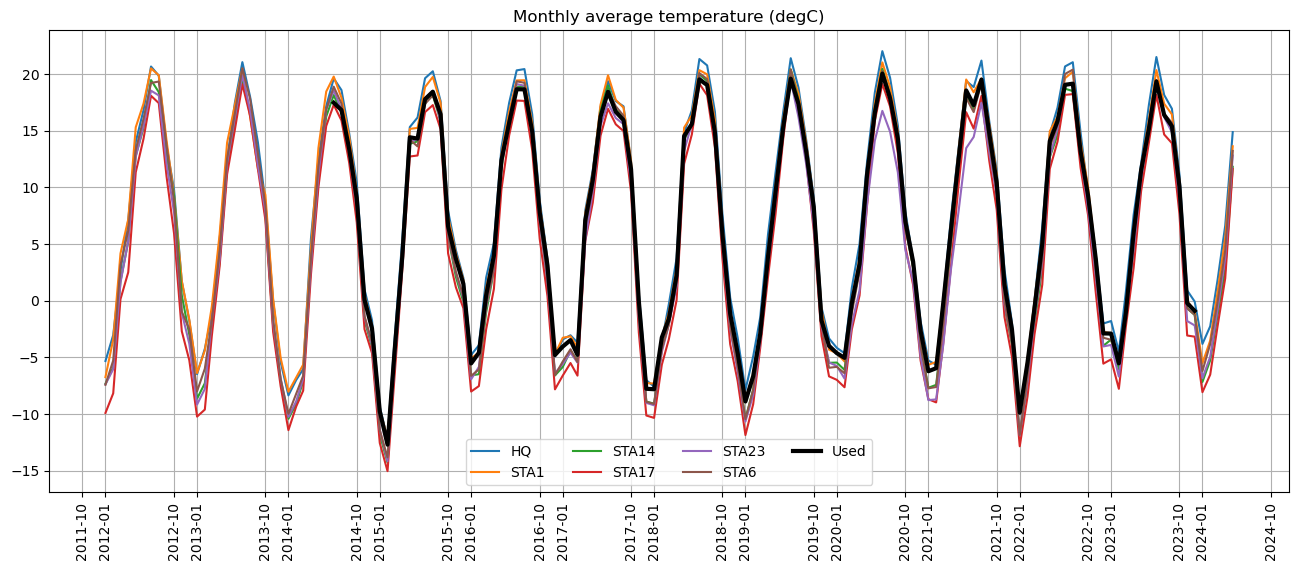

In [17]:
tair = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'data', 'Hubbard_Brook',
                            'knb-lter-hbr.59.14', 'HBEF_air_temp_daily_1957-2024.csv'), 
                            index_col = [0,1], parse_dates = True)['AVE'].unstack()
tair = tair.dropna(axis = 0, how = 'any')
tair = tair.loc[tair.index.year >= 2012, :]
tair = tair.resample('1MS').mean()

tair15min = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'data', 'Hubbard_Brook',
                                     'knb-lter-hbr.322.4', 'HBEF_STA1airTemp_15min.csv'), 
                        index_col = 1, parse_dates=True)
tair15min = tair15min['airTemp'].resample('1MS').mean()


fig, ax = plt.subplots(figsize = (16, 6))
for ws in tair.columns:
    ax.plot(tair.index, tair[ws], label = ws)
ax.plot(tair15min.index, tair15min, lw = 3, color = 'k', label = 'Used')
ax.set_title('Monthly average temperature (degC)')
ax.legend(ncol = 4)
plt.setp(ax.get_xticklabels(), rotation = 90)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.grid(True)

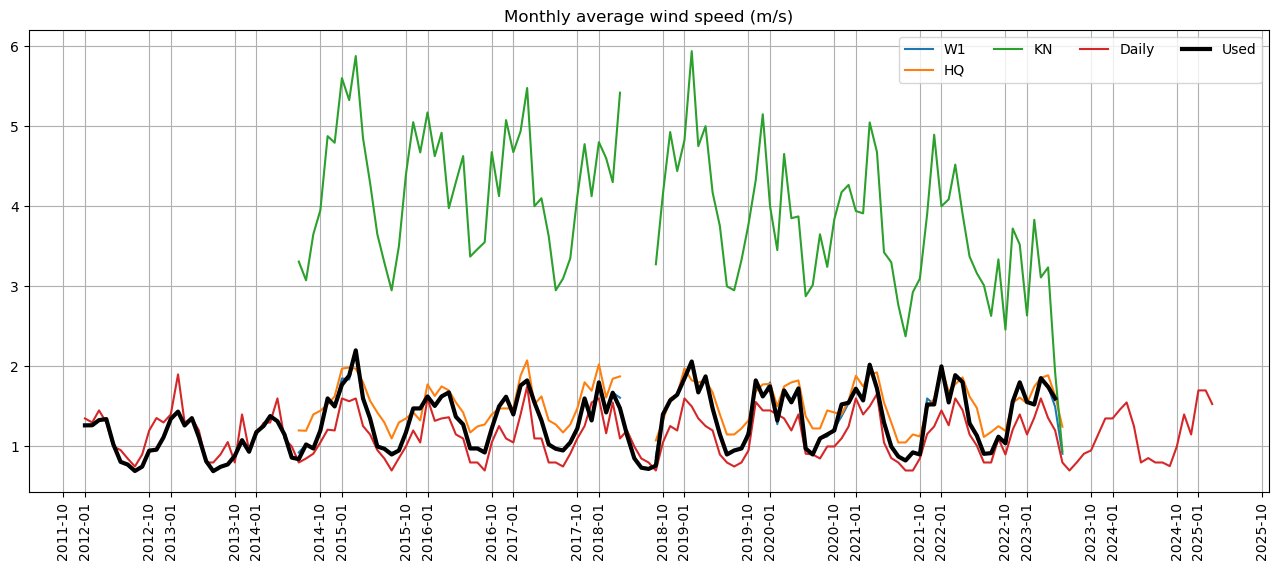

In [32]:
# 15 min wind speed
wind = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'data', 'Hubbard_Brook',
                                'knb-lter-hbr.337.3', 'HBEF_STA1_wind_15min.csv'),
                 index_col = 0, parse_dates=True)
wind = wind['WS_ms_Avg'].resample('1H').mean()

wind_hq = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'data', 'Hubbard_Brook',
                                   "knb-lter-hbr.337.3","HBEF_HQ_wind_15min.csv"),
                 index_col = 0, parse_dates=True)
wind_hq = wind_hq['WS_ms_Avg'].resample('1H').mean()

wind_kn = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'data', 'Hubbard_Brook',
                                   "knb-lter-hbr.337.3","HBEF_Kineo_wind_15min.csv"),
                 index_col = 0, parse_dates=True)
wind_kn = wind_kn['WS_ms_Avg'].resample('1H').mean()

wind_combined = pd.concat([wind, wind_hq, wind_kn], axis = 1, join = 'inner')
wind_combined.columns = ['W1', 'HQ', 'KN']
wind_combined = wind_combined.dropna(axis = 0, how = 'any')

wind_combined = wind_combined.resample('1MS').quantile(0.95)

wind_combined = wind_combined.loc[wind_combined.index.year >= 2012, :]

# 1 hour wind speed
wind_daily = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'data', 
                                      'Hubbard_Brook', 'knb-lter-hbr.56.12',
                                      'HBEF_wind_daily_1981-2025.csv'),
                         index_col = 0, parse_dates=True)
wind_daily = wind_daily['WS_ms_Avg'].resample('1MS').quantile(0.95)

wind_daily = wind_daily.loc[wind_daily.index.year >= 2012]

# Downscaled wind speed
wind_downscaled = pd.read_csv('./temp/downscaling_result.csv', index_col=0,
                              parse_dates=True)['Wind']
wind_downscaled = wind_downscaled.loc[wind_downscaled.index.year >= 2012]
wind_downscaled = wind_downscaled.resample('1MS').quantile(0.95)

# plot
fig, ax = plt.subplots(figsize = (16, 6))
for ws in wind_combined.columns:
    ax.plot(wind_combined.index, wind_combined[ws], label = ws)
ax.plot(wind_daily.index, wind_daily,label = 'Daily')
ax.plot(wind_downscaled.index, wind_downscaled, label = 'Used', lw = 3, color = 'k')
ax.set_title('Monthly average wind speed (m/s)')
ax.legend(ncol = 4)
plt.setp(ax.get_xticklabels(), rotation = 90)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.grid(True)

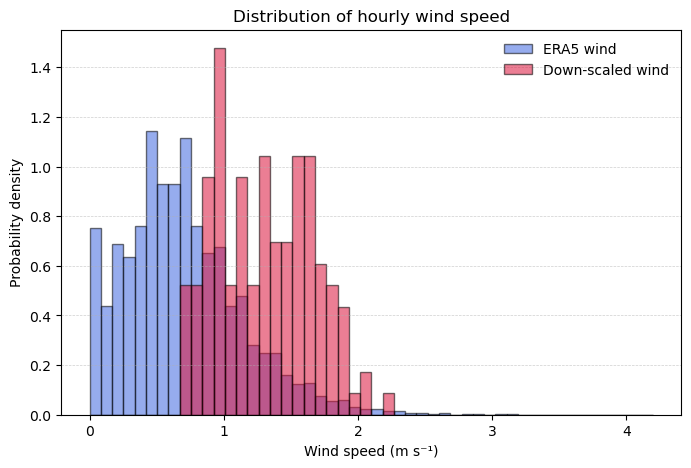

In [43]:
# diurnal cycle looks pretty consistent

n_bins = 50
x_min   = min(wind.min(), wind_downscaled.min())
x_max   = max(wind.max(), wind_downscaled.max())
bins    = np.linspace(x_min, x_max, n_bins + 1)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    wind,
    bins=bins,
    density=True,          # probability density instead of raw counts
    alpha=0.55,
    color="royalblue",
    edgecolor="black",
    label="ERA5 wind"      # or whatever the series represents
)

ax.hist(
    wind_downscaled,
    bins=bins,
    density=True,
    alpha=0.55,
    color="crimson",
    edgecolor="black",
    label="Down-scaled wind"
)

ax.set_xlabel("Wind speed (m s⁻¹)")
ax.set_ylabel("Probability density")
ax.set_title("Distribution of hourly wind speed")
ax.legend(frameon=False)
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)